"""
Pipeline Completo de Entrenamiento para Clasificación de Movimientos MPU-6050
- Ventanas deslizantes de 2 segundos
- Filtrado automático de actividad (descarta pausas)
- Extracción de features multi-escala
- Entrenamiento con Random Forest
"""

In [ ]:
import numpy as np
import pandas as pd
import os
import glob
from scipy import signal, stats
from scipy.fft import rfft, rfftfreq
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

In [ ]:
class GestureDatasetProcessor:
    """Procesa datasets de 60 segundos en ventanas de entrenamiento"""

    def __init__(self, window_size=2.0, stride=0.5, fs=50):
        """
        Args:
            window_size: Tamaño de ventana en segundos (default: 2s)
            stride: Desplazamiento entre ventanas en segundos (default: 0.5s = 50% overlap)
            fs: Frecuencia de muestreo en Hz
        """

        self.window_size = window_size
        self.stride = stride
        self.fs = fs
        self.window_samples = int(window_size * fs)
        self.stride_samples = int(stride * fs)

    def load_dataset(self, filepath):
        """Carga dataset limpio"""
        try:
            data = pd.read_csv(filepath, sep=r'\s+', header=None,
                             names=['Time', 'AccX', 'AccY', 'AccZ', 'GyrX', 'GyrY', 'GyrZ'])
            return data
        except Exception as e:
            print(f"❌ Error cargando {filepath}: {e}")
            return None

    def extract_windows(self, data, label, movement_name="Unknown"):
        """Extrae ventanas deslizantes de un dataset"""
        windows = []
        labels = []

        total_samples = len(data)
        num_windows = (total_samples - self.window_samples) // self.stride_samples + 1

        for i in range(num_windows):
            start_idx = i * self.stride_samples
            end_idx = start_idx + self.window_samples

            if end_idx > total_samples:
                break

            window = data.iloc[start_idx:end_idx].copy()
            windows.append(window)  # Agregar cada ventana
            labels.append(label)    # Agregar su label

        print(f"   Ventanas extraídas: {len(windows)}")  # Contar al final

        return windows, labels

class AdvancedFeatureExtractor:
    """Extractor de features avanzado con múltiples escalas temporales"""

    def __init__(self, fs=50):
        self.fs = fs

    def extract_features(self, window_data):
        """Extrae features completos de una ventana"""
        features = {}

        # Calcular magnitudes
        acc_mag = np.sqrt(window_data['AccX']**2 +
                         window_data['AccY']**2 +
                         window_data['AccZ']**2)
        gyr_mag = np.sqrt(window_data['GyrX']**2 +
                         window_data['GyrY']**2 +
                         window_data['GyrZ']**2)

        # === FEATURES ESTADÍSTICOS ===
        for axis, col in [('AccX', 'AccX'), ('AccY', 'AccY'), ('AccZ', 'AccZ'),
                          ('GyrX', 'GyrX'), ('GyrY', 'GyrY'), ('GyrZ', 'GyrZ')]:
            data = window_data[col].values
            features[f'{axis}_mean'] = np.mean(data)
            features[f'{axis}_std'] = np.std(data)
            features[f'{axis}_min'] = np.min(data)
            features[f'{axis}_max'] = np.max(data)
            features[f'{axis}_range'] = features[f'{axis}_max'] - features[f'{axis}_min']
            features[f'{axis}_rms'] = np.sqrt(np.mean(data**2))
            features[f'{axis}_skew'] = stats.skew(data)
            features[f'{axis}_kurtosis'] = stats.kurtosis(data)

        # === FEATURES DE MAGNITUD ===
        features['acc_mag_mean'] = np.mean(acc_mag)
        features['acc_mag_std'] = np.std(acc_mag)
        features['acc_mag_max'] = np.max(acc_mag)
        features['acc_mag_rms'] = np.sqrt(np.mean(acc_mag**2))

        features['gyr_mag_mean'] = np.mean(gyr_mag)
        features['gyr_mag_std'] = np.std(gyr_mag)
        features['gyr_mag_max'] = np.max(gyr_mag)
        features['gyr_mag_rms'] = np.sqrt(np.mean(gyr_mag**2))

        # === FEATURES TEMPORALES (CRÍTICOS PARA GESTOS) ===
        # Rise time (velocidad de ataque)
        features['acc_rise_time'] = self._calculate_rise_time(acc_mag)
        features['gyr_rise_time'] = self._calculate_rise_time(gyr_mag)

        # Peak prominence
        peaks_acc, props_acc = signal.find_peaks(acc_mag, prominence=1.0)
        features['acc_num_peaks'] = len(peaks_acc)
        features['acc_peak_prominence'] = np.mean(props_acc['prominences']) if len(peaks_acc) > 0 else 0

        peaks_gyr, props_gyr = signal.find_peaks(gyr_mag, prominence=0.5)
        features['gyr_num_peaks'] = len(peaks_gyr)
        features['gyr_peak_prominence'] = np.mean(props_gyr['prominences']) if len(peaks_gyr) > 0 else 0

        # Zero crossings (cambios de dirección)
        features['acc_zero_crossings'] = self._count_zero_crossings(window_data['AccX'])
        features['gyr_zero_crossings'] = self._count_zero_crossings(window_data['GyrX'])

        # === FEATURES ESPECTRALES ===
        freqs_acc, spectrum_acc = self._compute_spectrum(acc_mag)
        features['acc_spectral_centroid'] = self._spectral_centroid(freqs_acc, spectrum_acc)
        features['acc_spectral_energy'] = np.sum(spectrum_acc**2)
        features['acc_dominant_freq'] = freqs_acc[np.argmax(spectrum_acc)] if len(spectrum_acc) > 0 else 0

        freqs_gyr, spectrum_gyr = self._compute_spectrum(gyr_mag)
        features['gyr_spectral_centroid'] = self._spectral_centroid(freqs_gyr, spectrum_gyr)
        features['gyr_spectral_energy'] = np.sum(spectrum_gyr**2)
        features['gyr_dominant_freq'] = freqs_gyr[np.argmax(spectrum_gyr)] if len(spectrum_gyr) > 0 else 0

        # === FEATURES DE CORRELACIÓN ===
        features['acc_gyr_correlation'] = np.corrcoef(acc_mag, gyr_mag)[0, 1]

        # === FEATURES MULTI-ESCALA ===
        # Primera mitad (ataque inicial)
        half = len(window_data) // 2
        acc_mag_first_half = acc_mag[:half]
        features['acc_first_half_max'] = np.max(acc_mag_first_half)
        features['acc_first_half_energy'] = np.sum(acc_mag_first_half**2)

        return features

    def _calculate_rise_time(self, signal_data):
        """Calcula tiempo de subida (10% a 90% del pico)"""
        peak = np.max(signal_data)
        if peak < 1.0:
            return 0

        idx_10 = np.argmax(signal_data > peak * 0.1)
        idx_90 = np.argmax(signal_data > peak * 0.9)

        if idx_90 <= idx_10:
            return 0

        return (idx_90 - idx_10) / self.fs * 1000  # en ms

    def _count_zero_crossings(self, signal_data):
        """Cuenta cruces por cero"""
        return np.sum(np.diff(np.sign(signal_data)) != 0)

    def _compute_spectrum(self, signal_data):
        """Calcula espectro de frecuencias"""
        spectrum = np.abs(rfft(signal_data))
        freqs = rfftfreq(len(signal_data), 1/self.fs)
        return freqs, spectrum

    def _spectral_centroid(self, freqs, spectrum):
        """Calcula centroide espectral"""
        return np.sum(freqs * spectrum) / np.sum(spectrum) if np.sum(spectrum) > 0 else 0


class GestureClassifier:
    """Clasificador de gestos con Random Forest"""

    def __init__(self, n_estimators=200, max_depth=15):
        self.model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42,
            class_weight='balanced',
            n_jobs=-1
        )
        self.scaler = StandardScaler()
        self.feature_names = None
        self.class_names = None

    def train(self, X, y, class_names=None):
        """Entrena el modelo"""
        if isinstance(X, pd.DataFrame):
            self.feature_names = X.columns.tolist()
            X = X.values

        self.class_names = class_names

        # Normalizar features
        X_scaled = self.scaler.fit_transform(X)

        # Entrenar
        print("\n🔄 Entrenando Random Forest...")
        self.model.fit(X_scaled, y)

        # Validación cruzada
        scores = cross_val_score(self.model, X_scaled, y, cv=5)
        print(f"✅ Entrenamiento completo")
        print(f"   Accuracy CV (5-fold): {scores.mean():.3f} (+/- {scores.std():.3f})")

        return scores

    def evaluate(self, X_test, y_test):
        """Evalúa el modelo en test set"""
        if isinstance(X_test, pd.DataFrame):
            X_test = X_test.values

        X_scaled = self.scaler.transform(X_test)
        y_pred = self.model.predict(X_scaled)

        accuracy = accuracy_score(y_test, y_pred)

        print(f"\n📊 EVALUACIÓN EN TEST SET")
        print(f"{'='*60}")
        print(f"Accuracy: {accuracy:.3f}")
        print(f"\n{classification_report(y_test, y_pred, target_names=self.class_names)}")

        # Matriz de confusión
        cm = confusion_matrix(y_test, y_pred)
        self._plot_confusion_matrix(cm, self.class_names)

        return accuracy, y_pred

    def _plot_confusion_matrix(self, cm, class_names):
        """Grafica matriz de confusión"""
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=class_names, yticklabels=class_names)
        plt.title('Matriz de Confusión', fontsize=16)
        plt.ylabel('Verdadero', fontsize=12)
        plt.xlabel('Predicho', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig('confusion_matrix.png', dpi=300)
        print("\n✅ Matriz de confusión guardada en 'confusion_matrix.png'")
        plt.show()

    def feature_importance(self, top_n=20):
        """Muestra features más importantes"""
        if self.feature_names is None:
            print("⚠️  No hay nombres de features disponibles")
            return

        importances = self.model.feature_importances_
        indices = np.argsort(importances)[::-1][:top_n]

        plt.figure(figsize=(12, 8))
        plt.bar(range(top_n), importances[indices])
        plt.xticks(range(top_n), [self.feature_names[i] for i in indices],
                  rotation=45, ha='right')
        plt.title(f'Top {top_n} Features Más Importantes', fontsize=14)
        plt.ylabel('Importancia')
        plt.tight_layout()
        plt.savefig('feature_importance.png', dpi=300)
        print("\n✅ Importancia de features guardada en 'feature_importance.png'")
        plt.show()

    def save_model(self, filename='gesture_model.pkl'):
        """Guarda modelo entrenado"""
        model_data = {
            'model': self.model,
            'scaler': self.scaler,
            'feature_names': self.feature_names,
            'class_names': self.class_names
        }
        joblib.dump(model_data, filename)
        print(f"\n💾 Modelo guardado en '{filename}'")


# ============================================
# PIPELINE COMPLETO
# ============================================

def train_gesture_classifier(datasets_folder='DATASETS', test_size=0.2):
    """Pipeline completo de entrenamiento"""

    print("="*70)
    print("PIPELINE DE ENTRENAMIENTO - CLASIFICADOR DE GESTOS MPU-6050")
    print("="*70)

    # 1. Inicializar componentes
    processor = GestureDatasetProcessor(window_size=2.0, stride=0.5, fs=5)
    extractor = AdvancedFeatureExtractor(fs=50)

    # 2. Buscar datasets
    dataset_files = glob.glob(os.path.join(datasets_folder, '*_CLEAN.txt'))

    if not dataset_files:
        print(f"❌ No se encontraron datasets en '{datasets_folder}'")
        return

    print(f"\n📂 Encontrados {len(dataset_files)} datasets")

    # 3. Procesar cada dataset
    all_windows = []
    all_labels = []
    class_names = []

    for filepath in sorted(dataset_files):
        # Extraer nombre del movimiento
        filename = os.path.basename(filepath)
        if 'DATASET_' in filename and '_CLEAN' in filename:
            movement_name = filename.split('DATASET_')[1].split('_CLEAN')[0]
        else:
            movement_name = os.path.splitext(filename)[0]

        class_names.append(movement_name)

        print(f"\n📊 Procesando: {movement_name}")

        # Cargar y procesar
        data = processor.load_dataset(filepath)
        if data is None:
            continue

        windows, labels = processor.extract_windows(data, len(class_names) - 1)
        all_windows.extend(windows)
        all_labels.extend(labels)

    print(f"\n✅ Total de ventanas activas: {len(all_windows)}")
    print(f"   Clases: {len(class_names)}")

    # 4. Extraer features
    print(f"\n🔬 Extrayendo features...")
    all_features = []

    for i, window in enumerate(all_windows):
        if i % 100 == 0:
            print(f"   Progreso: {i}/{len(all_windows)}")
        features = extractor.extract_features(window)
        all_features.append(features)

    X = pd.DataFrame(all_features)
    y = np.array(all_labels)

    print(f"✅ Features extraídos: {X.shape[1]} features por ventana")

    # 5. Dividir en train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    print(f"\n📊 División de datos:")
    print(f"   Train: {len(X_train)} ventanas")
    print(f"   Test:  {len(X_test)} ventanas")

    # 6. Entrenar modelo
    classifier = GestureClassifier(n_estimators=200, max_depth=15)
    classifier.train(X_train, y_train, class_names=class_names)

    # 7. Evaluar
    accuracy, y_pred = classifier.evaluate(X_test, y_test)

    # 8. Feature importance
    classifier.feature_importance(top_n=20)

    # 9. Guardar modelo
    classifier.save_model('gesture_model.pkl')

    print("\n" + "="*70)
    print("✅ ENTRENAMIENTO COMPLETADO")
    print("="*70)
    print(f"Accuracy Final: {accuracy:.3f}")
    print(f"Modelo guardado: gesture_model.pkl")
    print(f"Gráficos generados:")
    print(f"  - confusion_matrix.png")
    print(f"  - feature_importance.png")

    return classifier, accuracy


PIPELINE DE ENTRENAMIENTO - CLASIFICADOR DE GESTOS MPU-6050

📂 Encontrados 10 datasets

📊 Procesando: CAJA
   Ventanas extraídas: 1495

📊 Procesando: CAMELLO
   Ventanas extraídas: 1496

📊 Procesando: CIRCULOdePELVIS
   Ventanas extraídas: 1494

📊 Procesando: GIROS
   Ventanas extraídas: 1491

📊 Procesando: GOLPEdeCADERA
   Ventanas extraídas: 1493

📊 Procesando: OCHO
   Ventanas extraídas: 1492

📊 Procesando: OMI
   Ventanas extraídas: 1496

📊 Procesando: PASOEGIPCIO
   Ventanas extraídas: 1496

📊 Procesando: REPOSO
   Ventanas extraídas: 1369

📊 Procesando: SHIMMY
   Ventanas extraídas: 1496

✅ Total de ventanas activas: 14818
   Clases: 10

🔬 Extrayendo features...
   Progreso: 0/14818
   Progreso: 100/14818
   Progreso: 200/14818
   Progreso: 300/14818
   Progreso: 400/14818
   Progreso: 500/14818
   Progreso: 600/14818
   Progreso: 700/14818
   Progreso: 800/14818
   Progreso: 900/14818
   Progreso: 1000/14818
   Progreso: 1100/14818
   Progreso: 1200/14818
   Progreso: 1300/14818

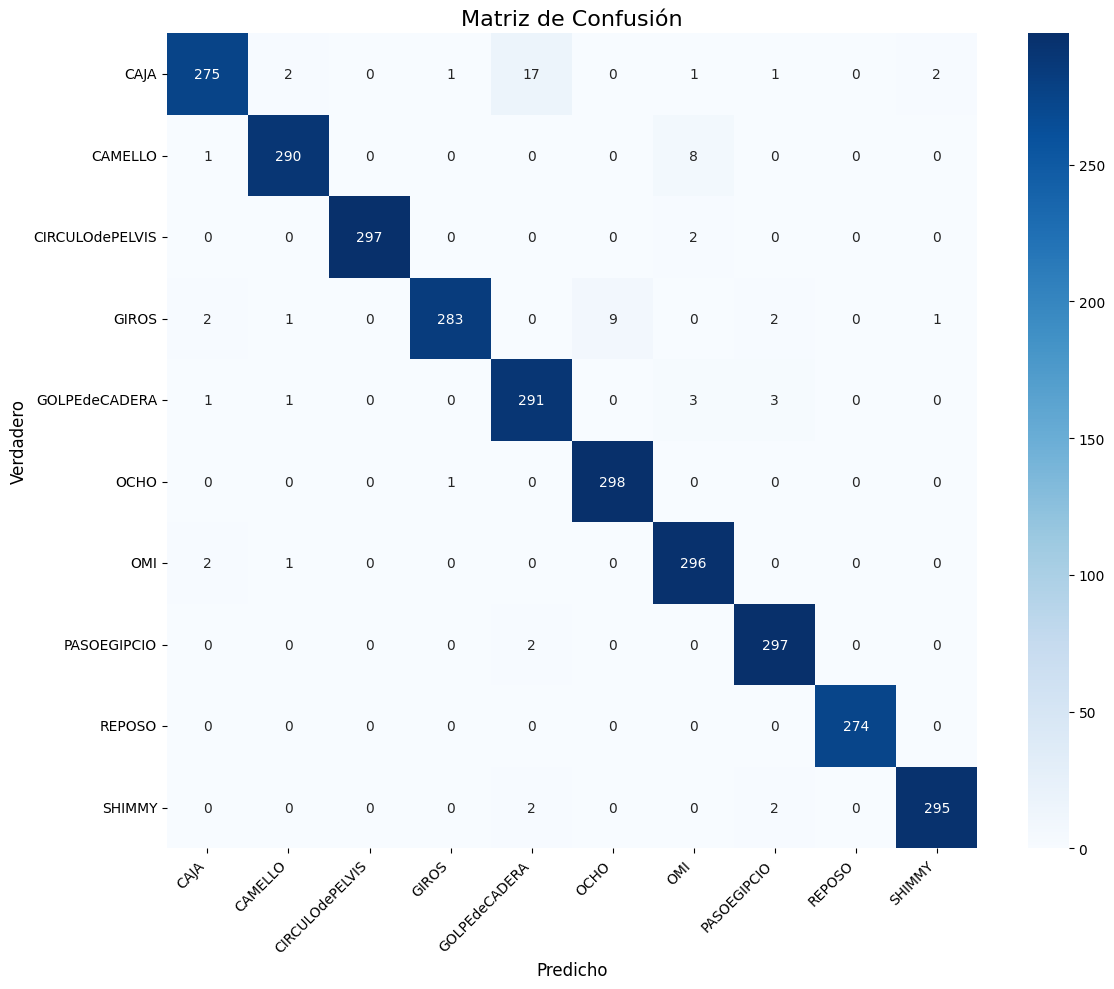


✅ Importancia de features guardada en 'feature_importance.png'


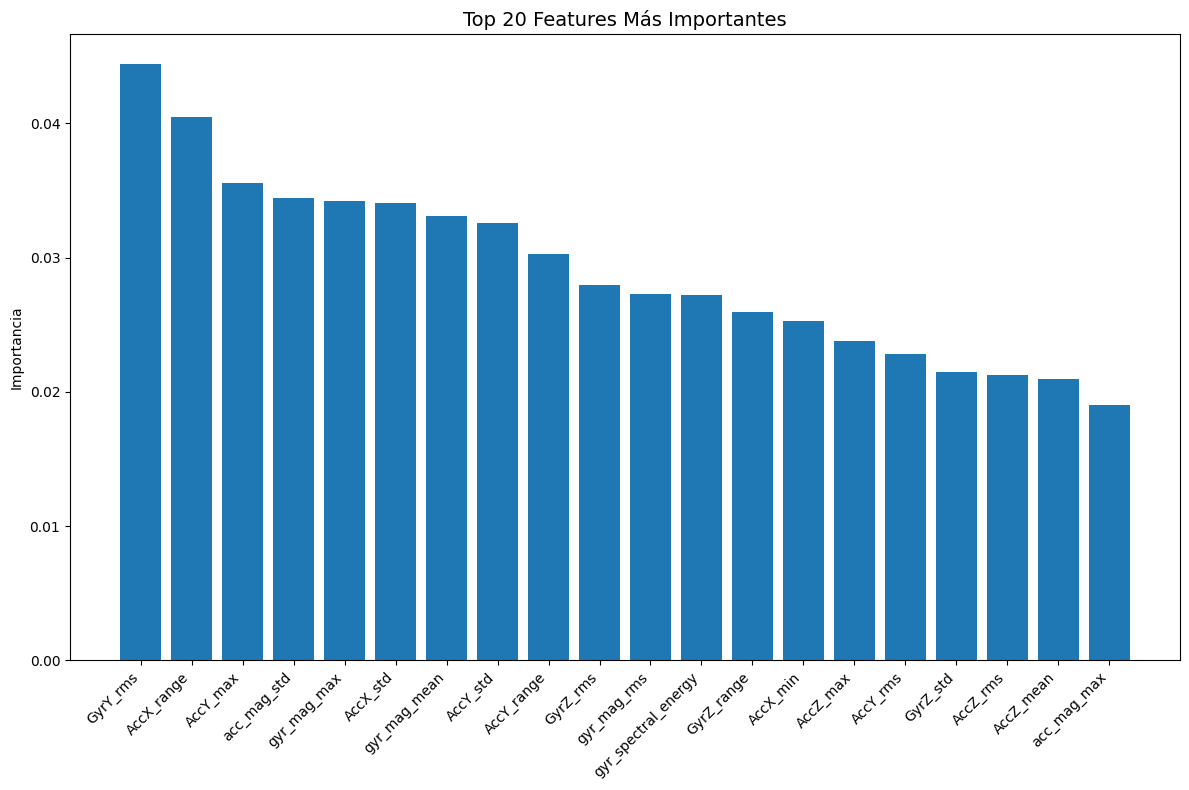


💾 Modelo guardado en 'gesture_model.pkl'

✅ ENTRENAMIENTO COMPLETADO
Accuracy Final: 0.977
Modelo guardado: gesture_model.pkl
Gráficos generados:
  - confusion_matrix.png
  - feature_importance.png


In [ ]:
# ============================================
# EJECUTAR
# ============================================

if __name__ == "__main__":
    # Entrenar modelo
    classifier, accuracy = train_gesture_classifier(
        datasets_folder='DATASETS',
        test_size=0.2
    )